# Venue Daily Visitors - Exploratory Data Analysis


## Import Libraries

Importing pandas and numpy for data handling, matplotlib and seaborn for the static charts, and hvplot with panel for the two interactive ones in Figures 7 and 8.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# install hvplot and panel if they are not already there
try:
    import hvplot.pandas
    import panel as pn
    pn.extension()
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'hvplot', 'panel'], capture_output=True)
    import hvplot.pandas
    import panel as pn
    pn.extension()

# set some basic style defaults so all charts look consistent
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False
})
sns.set_style('whitegrid')

# using the same colour for each tier across every figure so the reader
# only has to learn the colour coding once
TIER_COLOURS = {
    'High'    : '#27ae60',
    'Medium'  : '#e67e22',
    'Low'     : '#e74c3c',
    'Very Low': '#2c3e50'
}

print('libraries loaded ok')

libraries loaded ok


## Load the Data

Loading all six CSV files from the provided dataset(url) . The Date column gets converted to a datetime index straight away so the rolling average and resample functions work properly later on.

In [6]:
BASE = 'https://tinyurl.com/ChrisCoDV/001496957/'

visitors = pd.read_csv(BASE + 'VenueDailyVisitors.csv')
age      = pd.read_csv(BASE + 'VenueAge.csv')
distance = pd.read_csv(BASE + 'VenueDistance.csv')
duration = pd.read_csv(BASE + 'VenueDuration.csv')
gender   = pd.read_csv(BASE + 'VenueGender.csv')
spend    = pd.read_csv(BASE + 'VenueSpend.csv')

# set the date as the index so time series functions work
visitor_df = visitors.copy()
visitor_df['Date'] = pd.to_datetime(visitor_df['Date'])
visitor_df = visitor_df.set_index('Date')

print('shape:', visitor_df.shape)
print('dates:', visitor_df.index[0].date(), 'to', visitor_df.index[-1].date())
visitor_df.head()

shape: (365, 35)
dates: 2023-01-01 to 2023-12-31


,XXJ,VUJ,ULW,OFF,WRQ,VDM,PFN,LRT,VAU,UXT,...,SRZ,MFY,YRY,TDE,LXE,KFO,QRS,TLP,PLY,NRB
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-01,79,461,61,251,66,84,499,0,558,63,...,88,207,78,61,69,0,268,78,308,0
2023-01-02,76,521,54,267,58,66,399,0,513,82,...,94,165,80,109,64,0,262,79,289,0
2023-01-03,72,418,76,147,50,59,378,0,402,60,...,111,116,76,74,46,0,196,80,248,0
2023-01-04,79,384,58,139,69,64,288,0,321,64,...,91,106,83,80,40,0,197,82,216,0
2023-01-05,77,422,48,185,42,70,330,0,377,61,...,78,82,81,85,80,0,159,83,218,0


In [7]:
# quick look at the stats to understand the spread
visitor_df.describe().round(1)

,XXJ,VUJ,ULW,OFF,WRQ,VDM,PFN,LRT,VAU,UXT,...,SRZ,MFY,YRY,TDE,LXE,KFO,QRS,TLP,PLY,NRB
count,365.0,365.0,365.0,365.0,365.0,365.0,365.0,365.0,365.0,365.0,...,365.0,365.0,365.0,365.0,365.0,365.0,365.0,365.0,365.0,365.0
mean,75.5,449.3,65.9,201.3,60.4,68.7,439.3,43.7,439.8,66.5,...,92.3,142.6,79.2,80.5,29.9,11.4,221.8,78.8,265.1,25.0
std,9.8,86.9,10.9,41.7,7.0,13.1,85.5,58.8,73.6,14.2,...,14.2,37.6,7.0,13.9,31.1,24.0,37.2,5.8,35.8,39.4
min,46.0,213.0,33.0,107.0,39.0,31.0,208.0,0.0,291.0,19.0,...,56.0,69.0,62.0,46.0,0.0,0.0,152.0,56.0,206.0,0.0
25%,69.0,386.0,59.0,166.0,56.0,59.0,378.0,0.0,374.0,59.0,...,83.0,112.0,75.0,71.0,0.0,0.0,188.0,75.0,226.0,0.0
50%,76.0,449.0,66.0,204.0,60.0,68.0,444.0,7.0,433.0,67.0,...,92.0,138.0,79.0,81.0,0.0,0.0,220.0,78.0,258.0,0.0
75%,82.0,516.0,73.0,231.0,65.0,77.0,507.0,79.0,505.0,76.0,...,102.0,174.0,83.0,90.0,61.0,0.0,253.0,83.0,298.0,46.0
max,109.0,641.0,100.0,312.0,88.0,110.0,610.0,243.0,593.0,101.0,...,132.0,232.0,102.0,115.0,84.0,111.0,302.0,97.0,333.0,203.0


## Build the Summary DataFrame

Renaming columns so the merge works cleanly, then joining all the venue attribute files together. I also add a TotalVisitors column by summing each venue's daily counts across the year.

In [9]:
# rename columns before merging
age.columns      = ['Venue', 'Age']
distance.columns = ['Venue', 'Distance']
duration.columns = ['Venue', 'Duration']
gender.columns   = ['Venue', 'FemalePercent']
spend.columns    = ['Venue', 'Spend']

# sum each venue's daily visitors to get the annual total
total_visitors = visitor_df.sum().reset_index()
total_visitors.columns = ['Venue', 'TotalVisitors']

# merge everything into one summary table
from functools import reduce
summary_df = reduce(
    lambda l, r: l.merge(r, on='Venue'),
    [age, distance, duration, gender, spend, total_visitors]
)

print('summary shape:', summary_df.shape)
summary_df.head()

summary shape: (35, 7)


,Venue,Age,Distance,Duration,FemalePercent,Spend,TotalVisitors
0,XXJ,48,11,96,42,32,27556
1,VUJ,38,55,142,58,29,164005
2,ULW,35,4,79,52,25,24048
3,OFF,36,19,117,49,14,73465
4,WRQ,34,8,92,50,21,22047


## Automatic Volume Segmentation

Based on L02 / 06BarChart automatic.py

Rather than manually deciding which venues are high or low volume, I used a loop with threshold values to classify them automatically. This is the same approach from the lecture where venues (or pages) get sorted into groups based on their total count. The thresholds I used are: above 150,000 = High, above 48,000 = Medium, above 20,000 = Low, anything else = Very Low.

In [11]:
# Figure 2 setup: L02 / 06BarChart automatic.py
# automatic classification loop using thresholds

categories = ['High', 'Medium', 'Low', 'Very Low']
categories_selected = [[], [], [], []]

for venue in visitor_df.columns:
    total = visitor_df[venue].sum()
    if total > 150000:
        categories_selected[0].append(venue)
    elif total > 48000:
        categories_selected[1].append(venue)
    elif total > 20000:
        categories_selected[2].append(venue)
    else:
        categories_selected[3].append(venue)
    print('Venue', venue, 'is', categories[0 if total > 150000 else 1 if total > 48000 else 2 if total > 20000 else 3], 'volume')

HighSelected    = categories_selected[0]
MediumSelected  = categories_selected[1]
LowSelected     = categories_selected[2]
VeryLowSelected = categories_selected[3]

print('\nHigh:    ', HighSelected)
print('Medium:  ', MediumSelected)
print('Low:     ', LowSelected)
print('Very Low:', VeryLowSelected)

# add the tier label to summary_df so I can use it for colouring in later charts
def assign_tier(v):
    if v in HighSelected:
        return 'High'
    elif v in MediumSelected:
        return 'Medium'
    elif v in LowSelected:
        return 'Low'
    return 'Very Low'

summary_df['Tier'] = summary_df['Venue'].apply(assign_tier)

Venue XXJ is Low volume
Venue VUJ is High volume
Venue ULW is Low volume
Venue OFF is Medium volume
Venue WRQ is Low volume
Venue VDM is Low volume
Venue PFN is High volume
Venue LRT is Very Low volume
Venue VAU is High volume
Venue UXT is Low volume
Venue KLZ is Very Low volume
Venue QXC is Medium volume
Venue OXV is Medium volume
Venue WJG is Low volume
Venue URJ is Low volume
Venue RLH is Low volume
Venue LLJ is Very Low volume
Venue UOR is High volume
Venue NLQ is Medium volume
Venue PRK is Medium volume
Venue XDV is Very Low volume
Venue RDX is Low volume
Venue VXB is Low volume
Venue MXL is Very Low volume
Venue SXK is Low volume
Venue SRZ is Low volume
Venue MFY is Medium volume
Venue YRY is Low volume
Venue TDE is Low volume
Venue LXE is Very Low volume
Venue KFO is Very Low volume
Venue QRS is Medium volume
Venue TLP is Low volume
Venue PLY is Medium volume
Venue NRB is Very Low volume

High:     ['VUJ', 'PFN', 'VAU', 'UOR']
Medium:   ['OFF', 'QXC', 'OXV', 'NLQ', 'PRK', 'MFY',

## Figure 1 - Total Annual Visitors by Venue (Sorted Bar Chart)

Based on L02 / 08BarChart all sorted.py

### Justification

I started with a sorted bar chart because it gives the clearest possible overview of which venues matter most. Sorting in descending order means the eye immediately goes to the biggest contributors on the left. I added colour coding by tier so the reader can see both the individual total and which group each venue belongs to without needing to read every label. This is directly from the lecture example 08BarChart all sorted.py which showed sorting before plotting as a key step. The only adaptation I made was replacing the page hit data with venue visitor totals and adding the four-colour tier legend.

### What this shows

Figure 1 makes it immediately obvious that visitor numbers are very unevenly spread. A handful of venues in green attract far more visitors than all the others combined. Most venues sit in the red Low category. The long tail of dark grey Very Low venues is also striking - some of these venues barely registered any visitors across the whole year.

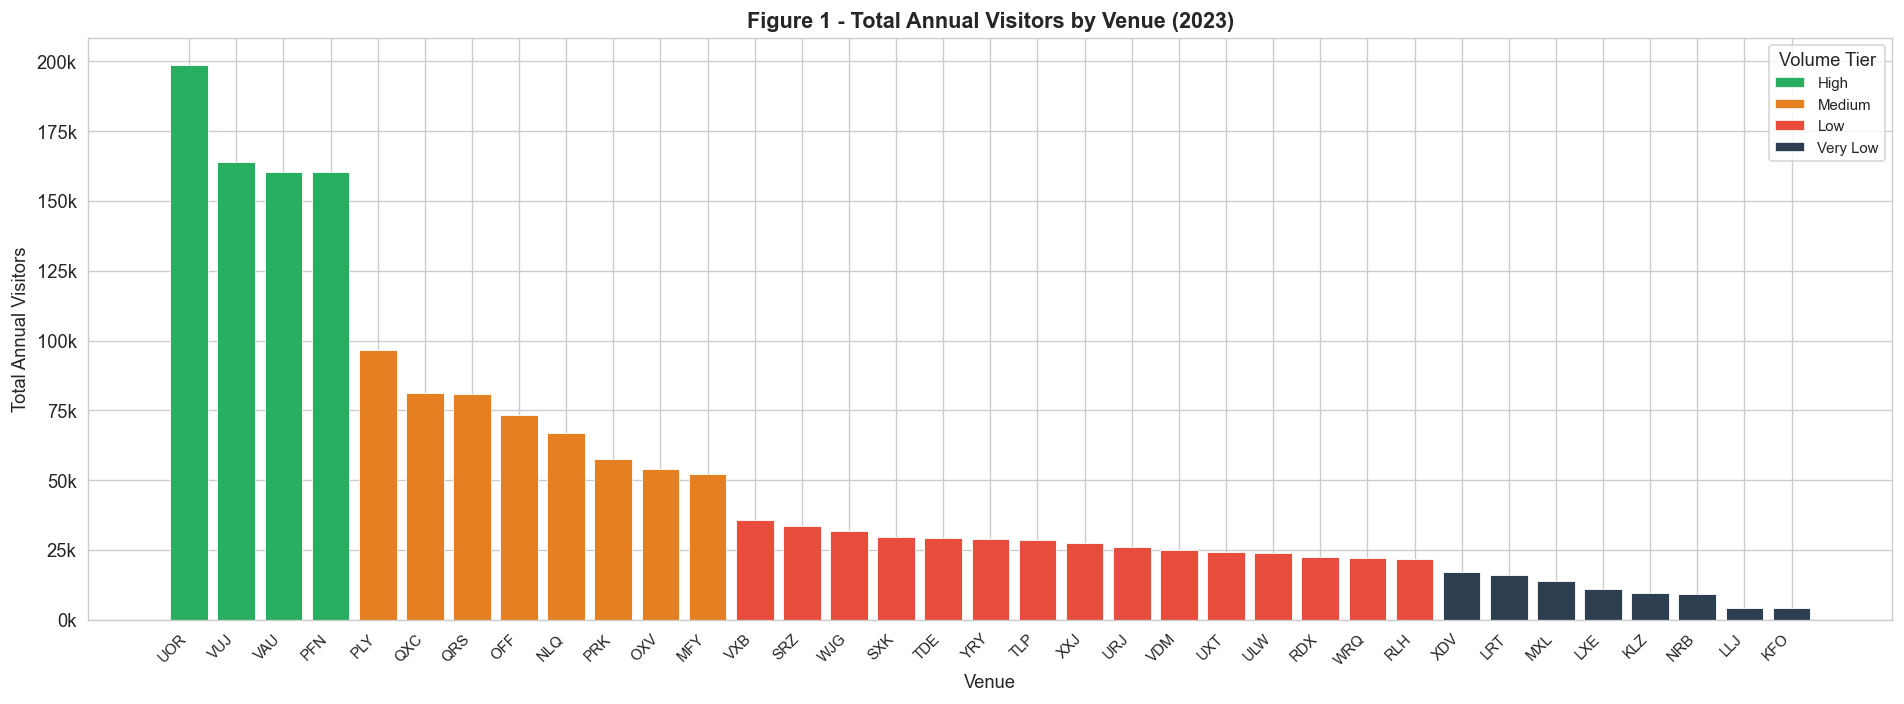

In [13]:
# Figure 1: L02 / 08BarChart all sorted.py
# sorting the venues by total visitors before plotting

totals  = summary_df.sort_values('TotalVisitors', ascending=False)
colours = [TIER_COLOURS[t] for t in totals['Tier']]
x_pos   = np.arange(len(totals))

plt.figure(figsize=(16, 6))
plt.bar(x_pos, totals['TotalVisitors'], color=colours, edgecolor='white', linewidth=0.5)
plt.xticks(x_pos, totals['Venue'], rotation=45, ha='right', fontsize=9)
plt.xlabel('Venue')
plt.ylabel('Total Annual Visitors')
plt.title('Figure 1 - Total Annual Visitors by Venue (2023)', fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

legend_patches = [mpatches.Patch(facecolor=c, label=t) for t, c in TIER_COLOURS.items()]
plt.legend(handles=legend_patches, title='Volume Tier', fontsize=9)

plt.tight_layout()
plt.show()

## Figure 2 - Segmented Bar Charts by Volume Tier

Based on L02 / 02BarChart high volume.py, 03BarChart medium volume.py, 04BarChart low volume.py (using automatic version from 06BarChart automatic.py)

### Justification

Figure 1 shows all venues together but it makes it hard to compare venues within the same tier because the y-axis scale is dominated by the High venues. By splitting into four separate panels, each tier gets its own scale and you can actually see the differences within each group. The lecture showed this exact approach with separate bar charts for high, medium and low volume pages. I adapted it into a 2x2 subplot grid so all four panels are visible at once rather than in separate figures.

### What this shows

Within each tier, the venues are not all the same. In the High tier one or two venues stand clearly above the others. In Medium the spread is wider. The Very Low panel is interesting because some venues have almost zero visitors, which likely means they opened late in the year rather than being genuinely unpopular.

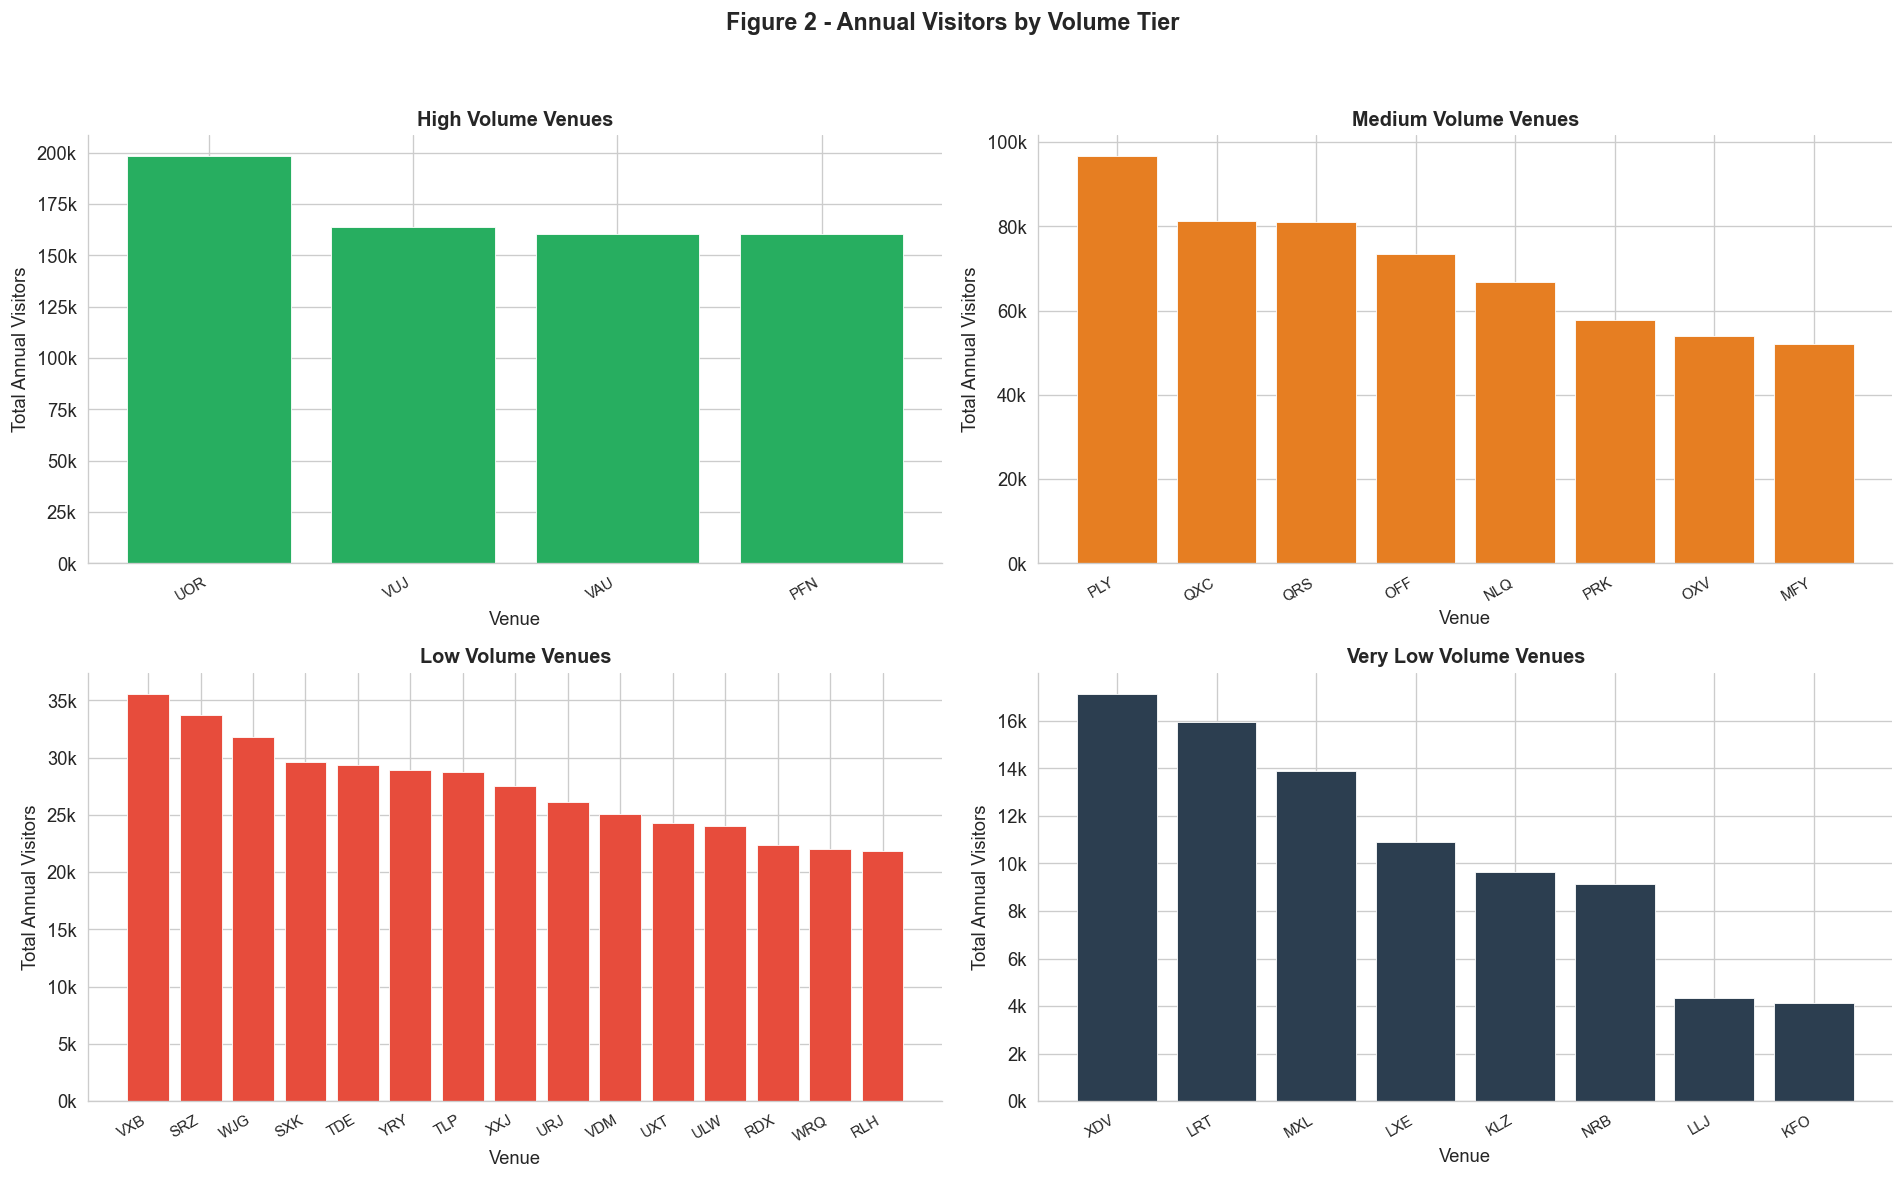

In [15]:
# Figure 2: L02 / 02-05 BarChart per volume tier
# plotting a separate bar chart for each tier, based on the automatic classification above

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Figure 2 - Annual Visitors by Volume Tier', fontsize=14, fontweight='bold')

tier_colour_list = ['#27ae60', '#e67e22', '#e74c3c', '#2c3e50']

for i, (cat, selected, colour) in enumerate(zip(categories, categories_selected, tier_colour_list)):
    ax = axes[i // 2][i % 2]
    values = visitor_df[selected].sum().sort_values(ascending=False)
    x_pos = np.arange(len(selected))

    ax.bar(x_pos, values, color=colour, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(values.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(cat + ' Volume Venues', fontsize=12, fontweight='bold')
    ax.set_xlabel('Venue')
    ax.set_ylabel('Total Annual Visitors')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Figure 3 - Rolling Average and Linear Trendline

Based on L03 / 05LinePlot high volume rolling ave.py and 06LinePlot high volume trendline.py

### Justification

After seeing which venues are biggest in Figures 1 and 2, the next question is how their visitor numbers changed across the year. A raw daily line plot would be too noisy to read because visitor counts jump around a lot from day to day. The solution from the lecture was to apply a rolling average using data.rolling(window=21).mean() which smooths out the noise while keeping the real trends visible. On top of that I added a linear trendline for each venue using np.polyfit(x, y, 1) and np.poly1d(z) exactly as shown in 06LinePlot high volume trendline.py. The thin faded lines behind each bold line show the original raw data so you can still see how noisy it was.

### What this shows

The High venues have nearly flat trendlines, meaning their visitor numbers stayed consistent all year. There is a small dip in the middle of the year across most venues which is probably a seasonal effect like school holidays. The Medium venues are more interesting because some of them have upward sloping trendlines, meaning they were growing during 2023. Without the rolling average this would have been invisible in the noise.

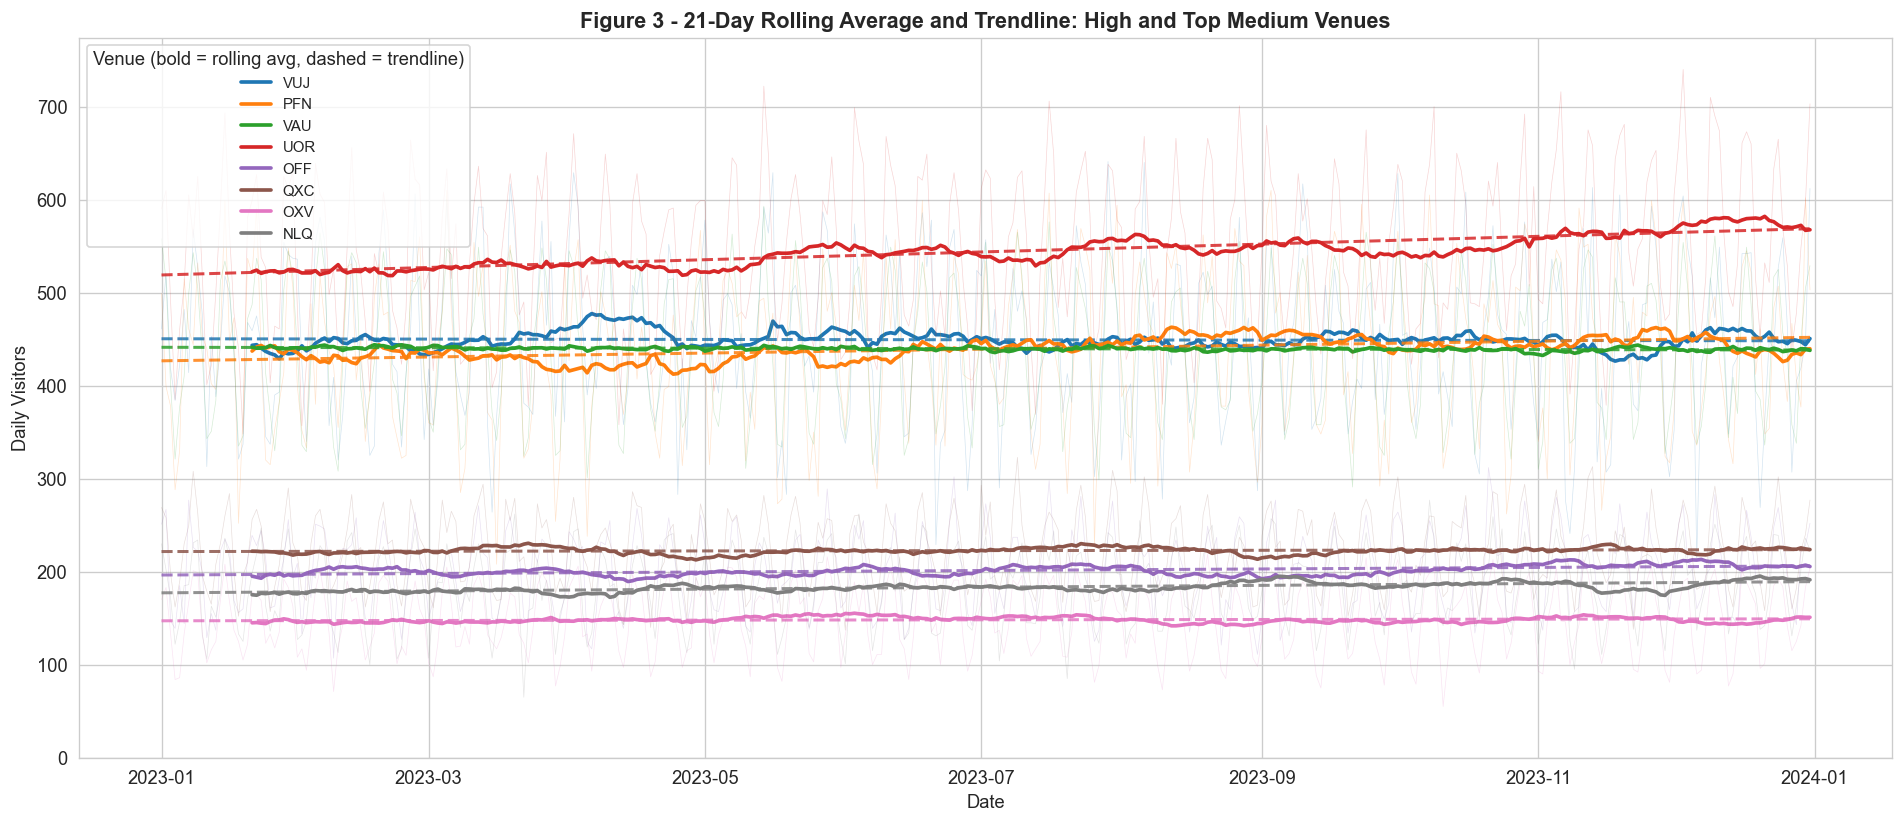

In [17]:
# Figure 3: L03 / 05LinePlot high volume rolling ave.py + 06LinePlot high volume trendline.py
# applying a 21-day rolling average and adding a trendline for each venue

window = 21
selected = HighSelected + MediumSelected[:4]
rolling = visitor_df[selected].rolling(window=window).mean()

prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(16, 7))

for idx, name in enumerate(selected):
    colour = prop_cycle[idx % len(prop_cycle)]

    # raw daily data shown faintly behind the rolling average
    plt.plot(visitor_df.index, visitor_df[name], linewidth=0.4, color=colour, alpha=0.2)

    # 21-day rolling average - the main line
    plt.plot(rolling.index, rolling[name], linewidth=2.2, color=colour, label=name)

    # linear trendline using np.polyfit
    x = np.arange(len(visitor_df[name]))
    z = np.polyfit(x, visitor_df[name], 1)
    p = np.poly1d(z)
    plt.plot(visitor_df.index, p(x), linestyle='--', linewidth=1.8, color=colour, alpha=0.85)

plt.ylim(ymin=0)
plt.xlabel('Date')
plt.ylabel('Daily Visitors')
plt.title('Figure 3 - 21-Day Rolling Average and Trendline: High and Top Medium Venues', fontweight='bold')
plt.legend(title='Venue (bold = rolling avg, dashed = trendline)', fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

## Figure 4 - Box Plots: Daily Visitor Distribution per Tier

Based on L05 / 04BoxPlot high volume.py and 05BoxPlot medium volume.py

### Justification

The rolling average in Figure 3 shows how visitor numbers move over time but it does not show how consistent or variable each venue is day to day. Box plots from L05 give a compact summary of the full distribution for each venue: the box covers the middle 50% of values, the line inside is the median, the whiskers stretch to 1.5 times the interquartile range, and any outlier days appear as individual dots. This lets me compare spread and variability across venues in a way that a line chart cannot. I adapted the lecture code to put High and Medium side by side in a single figure so the difference between the two tiers is directly visible.

### What this shows

High venues have taller boxes, meaning their daily visitor counts vary more from day to day. This is not necessarily bad - it likely reflects strong weekend versus weekday differences. Medium venues have narrower boxes, suggesting more consistent daily numbers. The outlier dots above the whiskers on some venues represent exceptional days, probably events or public holidays.

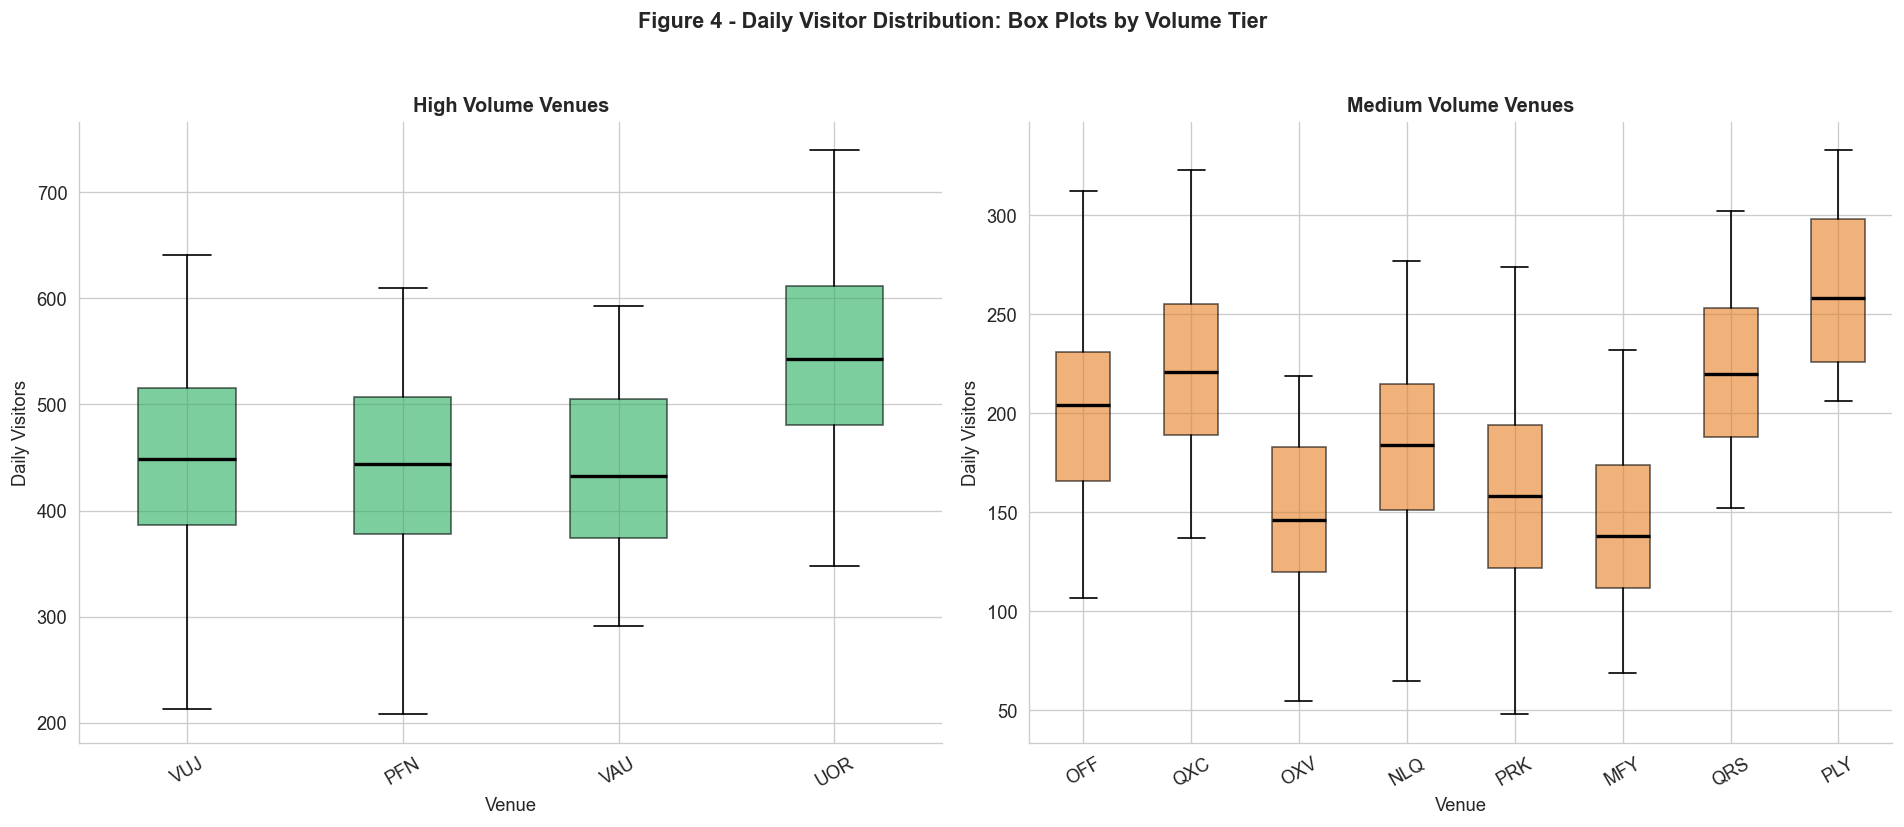

In [19]:
# Figure 4: L05 / 04BoxPlot high volume.py + 05BoxPlot medium volume.py
# box plots showing the spread of daily visitor counts for each venue

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Figure 4 - Daily Visitor Distribution: Box Plots by Volume Tier', fontsize=13, fontweight='bold')

for ax, (tier, selected, colour) in zip(axes, [
    ('High',   HighSelected,   '#27ae60'),
    ('Medium', MediumSelected, '#e67e22')
]):
    data_arrays = [visitor_df[v].dropna().values for v in selected]

    bp = ax.boxplot(
        data_arrays,
        labels=selected,
        patch_artist=True,
        notch=False,
        showfliers=True,
        flierprops=dict(marker='o', markersize=3, alpha=0.4, color=colour)
    )

    for patch in bp['boxes']:
        patch.set_facecolor(colour)
        patch.set_alpha(0.6)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    ax.set_title(tier + ' Volume Venues', fontsize=12, fontweight='bold')
    ax.set_xlabel('Venue')
    ax.set_ylabel('Daily Visitors')
    ax.tick_params(axis='x', rotation=30)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Figure 5 - Correlation Heatmap: Venue Summary Attributes

Based on L04 / 04HeatMap correlation all.py

### Justification

The summary data has six numerical columns. Checking every possible pairing with individual scatter plots would mean 15 separate charts. The correlation heatmap from L04 calculates all the pairwise Pearson correlations in one go using data.corr() and displays them as a colour grid. Red means both values tend to go up together, blue means they go in opposite directions, and white means no real relationship. The numbers in each cell give the exact value. I adapted it from the lecture example by applying it to the six venue attributes instead of page traffic columns.

### What this shows

The strongest positive relationship is between Spend and Duration. Venues where visitors stay longer tend to have higher average spend, which makes sense. There is also a moderate negative relationship between Age and TotalVisitors, meaning venues with an older visitor base tend to get fewer visitors overall. Distance and FemalePercent have weak correlations with everything else, so they are probably not useful predictors here.

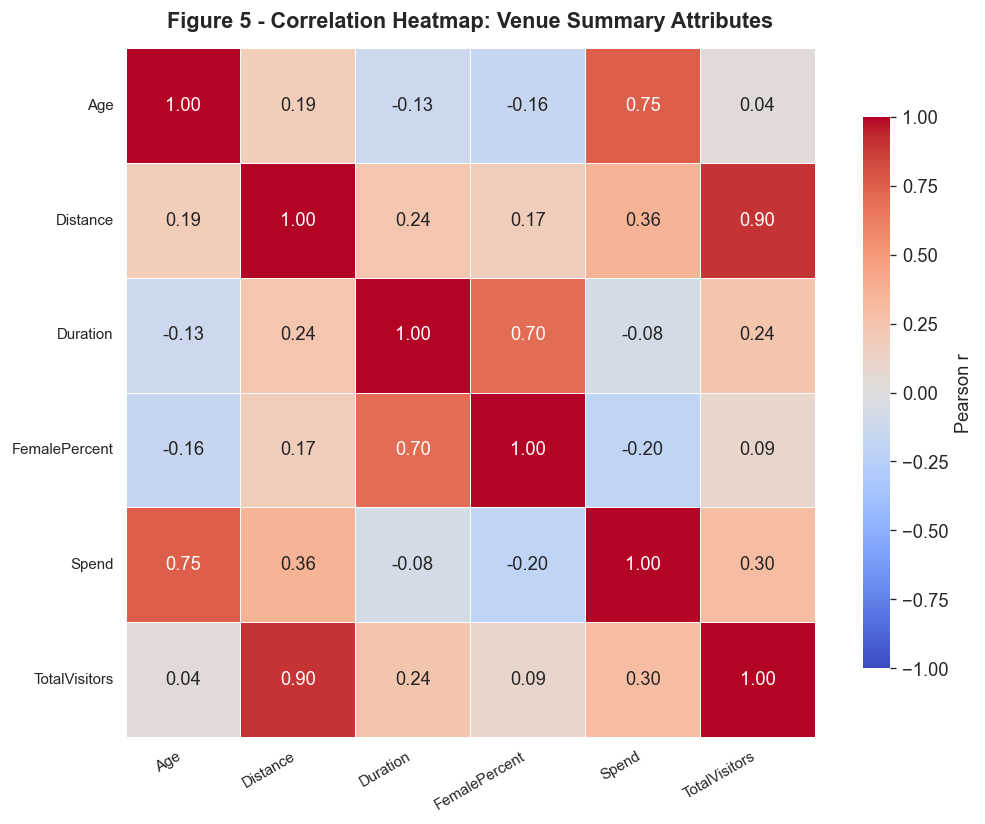

Correlations above 0.4 (positive or negative):
  Spend vs Age : 0.75
  TotalVisitors vs Distance : 0.9
  FemalePercent vs Duration : 0.7
  Duration vs FemalePercent : 0.7
  Age vs Spend : 0.75
  Distance vs TotalVisitors : 0.9


In [21]:
# Figure 5: L04 / 04HeatMap correlation all.py
# calculating the correlation matrix and displaying it as a heatmap

numeric_cols = ['Age', 'Distance', 'Duration', 'FemalePercent', 'Spend', 'TotalVisitors']
corr_matrix = summary_df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
plt.title('Figure 5 - Correlation Heatmap: Venue Summary Attributes', fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# print any correlations above 0.4 so they are easy to spot
print('Correlations above 0.4 (positive or negative):')
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        val = corr_matrix.loc[row, col]
        if row != col and abs(val) > 0.4:
            print(' ', row, 'vs', col, ':', round(val, 2))

## Figure 6 - Scatter Plot: Spend vs Duration

Based on L04 / 01ScatterPlot high volume.py and 07ScatterPlot selected correlation.py

### Justification

Figure 5 found a positive correlation between Spend and Duration but a heatmap number on its own does not show the shape of the relationship or which venues are driving it. A scatter plot from L04 puts each venue as a single labelled point so you can see exactly where each one sits. I coloured the points by tier to match the colour scheme used in all the other figures, and added a trendline using np.polyfit to make the direction of the relationship clear. The labelling approach follows 07ScatterPlot selected correlation.py which annotated each point with an identifier.

### What this shows

The positive relationship holds across all four tiers, not just the High venues. Venues in the top right corner have both long visit times and high spend per visitor, which is the best combination commercially. A few venues achieve high spend despite shorter visits, which suggests their pricing or product range does some of the work that dwell time does for others.

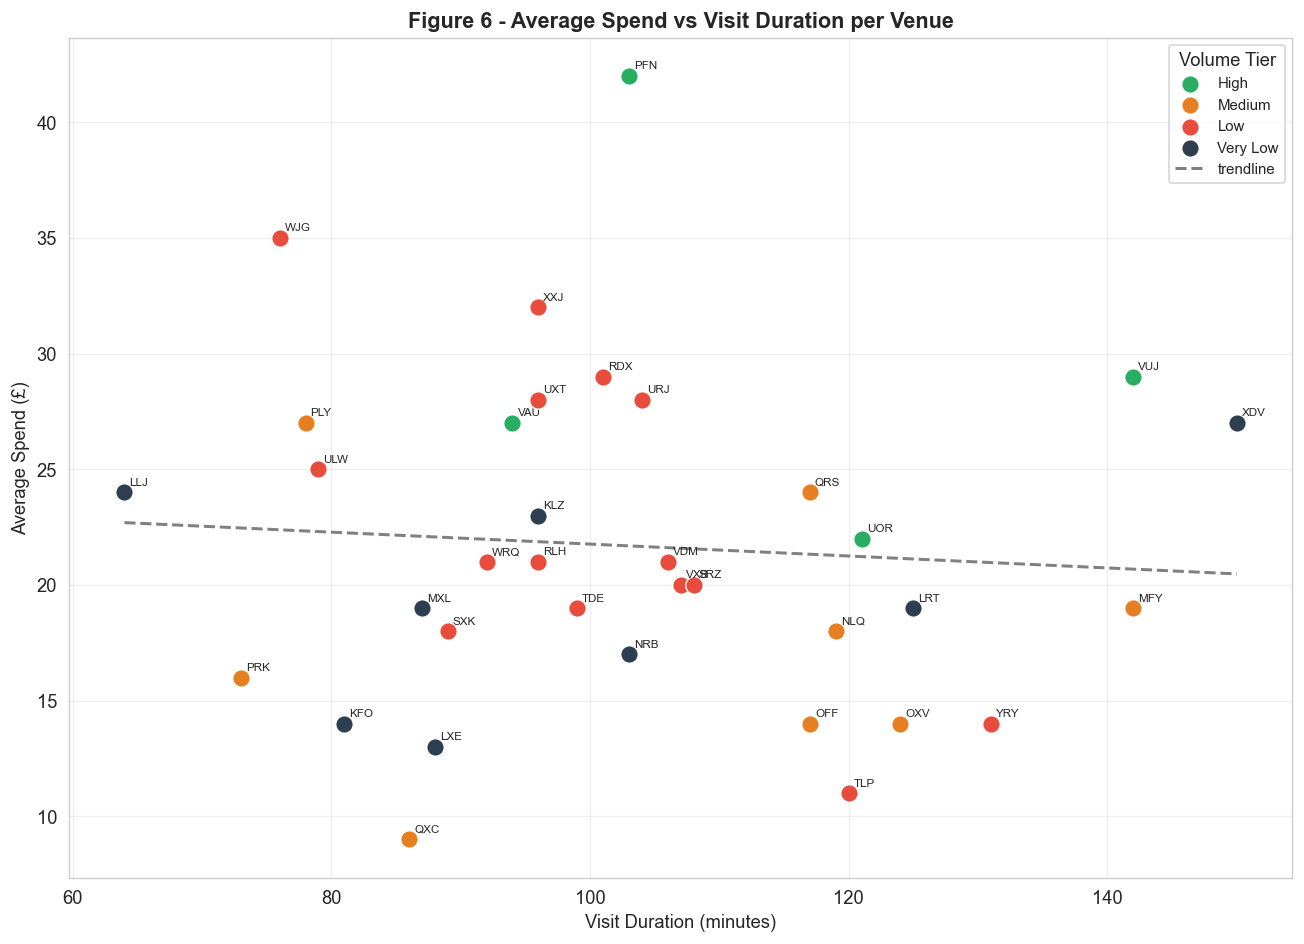

In [23]:
# Figure 6: L04 / 01ScatterPlot high volume.py + 07ScatterPlot selected correlation.py
# scatter plot with venue labels and a trendline

plt.figure(figsize=(11, 8))

for tier, colour in TIER_COLOURS.items():
    subset = summary_df[summary_df['Tier'] == tier]
    plt.scatter(
        subset['Duration'],
        subset['Spend'],
        c=colour,
        s=110,
        edgecolors='white',
        linewidth=0.8,
        label=tier,
        zorder=3
    )
    for _, row in subset.iterrows():
        plt.annotate(
            row['Venue'],
            (row['Duration'], row['Spend']),
            fontsize=7,
            ha='left',
            va='bottom',
            xytext=(3, 3),
            textcoords='offset points'
        )

# overall trendline using np.polyfit
x_all = summary_df['Duration'].values
y_all = summary_df['Spend'].values
z = np.polyfit(x_all, y_all, 1)
x_line = np.linspace(x_all.min(), x_all.max(), 100)
plt.plot(x_line, np.poly1d(z)(x_line), color='gray', linestyle='--', linewidth=1.8, label='trendline', zorder=2)

plt.xlabel('Visit Duration (minutes)')
plt.ylabel('Average Spend (£)')
plt.title('Figure 6 - Average Spend vs Visit Duration per Venue', fontweight='bold')
plt.legend(title='Volume Tier', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Figure 7 - Interactive Rolling Average Explorer

Based on L07 / 02LinePlot high volume.py

### Justification

Figure 3 was useful but it was locked to a 21-day window and only showed High and Medium venues. The interactive version removes those limitations. Using hvplot.line() and panel widgets (from L07), the user can change the smoothing window with a slider, switch between tiers with a dropdown, and zoom into any part of the year. This makes it much easier to spot patterns at different time scales without having to re-run the code. The Bokeh toolbar also gives zoom, pan, hover and save tools.

### How to use it
- Use the **Volume Tier** dropdown to switch between High, Medium and Low
- Drag the **Rolling Window** slider left for less smoothing, right for more
- Use the **Date Range** slider to zoom into a specific period
- Hover over any line to see the exact visitor count for that date
- Use Pan and Box Zoom in the toolbar to explore the chart

In [25]:
# Figure 7: L07 / 02LinePlot high volume.py
# interactive rolling average chart using hvplot and panel widgets

import hvplot.pandas
import panel as pn
pn.extension()

TIER_MAP = {
    'High'  : HighSelected,
    'Medium': MediumSelected,
    'Low'   : LowSelected
}

volume_select = pn.widgets.Select(
    name='Volume Tier',
    options=['High', 'Medium', 'Low'],
    value='High',
    width=160
)

window_slider = pn.widgets.IntSlider(
    name='Rolling Window (days)',
    value=21,
    start=1,
    end=60,
    step=1,
    width=220
)

date_slider = pn.widgets.DateRangeSlider(
    name='Date Range',
    width=300,
    value=(visitor_df.index[0], visitor_df.index[-1]),
    start=visitor_df.index[0],
    end=visitor_df.index[-1]
)

@pn.depends(volume_select, window_slider, date_slider)
def rolling_plot(volume, window, date_range):
    venues = TIER_MAP[volume]
    df = visitor_df[venues].copy()
    df = df.rolling(window=window).mean()
    start = pd.Timestamp(date_range[0])
    end = pd.Timestamp(date_range[1])
    df = df.loc[start:end]
    return df.hvplot.line(
        title='Figure 7 - ' + str(window) + '-Day Rolling Average | ' + volume + ' Volume Venues',
        xlabel='Date',
        ylabel='Mean Daily Visitors',
        width=720,
        height=400,
        grid=True,
        legend='top_left'
    )

controls7 = pn.Column(
    pn.pane.Markdown('### Controls'),
    volume_select,
    window_slider,
    date_slider
)

dashboard7 = pn.Row(controls7, rolling_plot)
dashboard7.servable()
dashboard7

Row
    [0] Column
        [0] Markdown(str)
        [1] Select(name='Volume Tier', options=['High', 'Medium', 'Low'], value='High', width=160)
        [2] IntSlider(end=60, name='Rolling Window (days)', start=1, value=21, width=220)
        [3] DateRangeSlider(end=Timestamp('2023-12-31 0..., name='Date Range', start=Timestamp('2023-01-01 0..., value=(Timestamp('2023-01-01 00:..., value_end=Timestamp('2023-12-31 0..., value_start=Timestamp('2023-01-01 0..., width=300)
    [1] ParamFunction(function, _pane=HoloViews, defer_load=False)

### What this shows

When you set the window to 7 days a weekly rhythm becomes visible - some days consistently get more visitors than others, which is probably a weekend effect. At 21 days that pattern smooths out and you can see the monthly trend more clearly. At 60 days only the broad seasonal shape is left. Switching to Medium venues reveals a lot more variation between venues than you could see in the static Figure 3 - some are growing noticeably over the year while others are fairly flat or declining.

## Figure 8 - Interactive Scatter Explorer

Based on L07 / 09ScatterPlots selected correlation.py

### Justification

Figure 6 only showed one pair of attributes (Duration vs Spend). There are six numerical columns in the summary data which means 15 possible pairings. Rather than making 15 static scatter plots I used hvplot.scatter() with two panel Select widgets so the user can pick which attributes go on each axis. This follows the L07 lecture approach of letting users explore relationships interactively. The points are coloured by tier throughout so the colour coding is consistent with every other figure in this notebook.

### How to use it
- Use the **X Axis** dropdown to pick the attribute on the horizontal axis
- Use the **Y Axis** dropdown to pick the attribute on the vertical axis
- Hover over any point to see the venue code and exact values
- Use Box Zoom to zoom into a cluster of venues
- Click Reset to go back to the full view

In [28]:
# Figure 8: L07 / 09ScatterPlots selected correlation.py
# interactive scatter with axis selectors so the user can explore any combination

ATTR_COLS = ['Age', 'Distance', 'Duration', 'FemalePercent', 'Spend', 'TotalVisitors']

x_select = pn.widgets.Select(
    name='X Axis',
    options=ATTR_COLS,
    value='Duration',
    width=180
)

y_select = pn.widgets.Select(
    name='Y Axis',
    options=ATTR_COLS,
    value='Spend',
    width=180
)

@pn.depends(x_select, y_select)
def scatter_plot(xcol, ycol):
    return summary_df.hvplot.scatter(
        x=xcol,
        y=ycol,
        by='Tier',
        hover_cols=['Venue', xcol, ycol, 'Tier'],
        title='Figure 8 - Venue Attribute Explorer: ' + xcol + ' vs ' + ycol,
        xlabel=xcol,
        ylabel=ycol,
        size=100,
        width=680,
        height=440,
        grid=True,
        legend='top_right'
    )

controls8 = pn.Column(
    pn.pane.Markdown('### Axis Selectors'),
    x_select,
    y_select
)

dashboard8 = pn.Row(controls8, scatter_plot)
dashboard8.servable()
dashboard8

Row
    [0] Column
        [0] Markdown(str)
        [1] Select(name='X Axis', options=['Age', 'Distance', ...], value='Duration', width=180)
        [2] Select(name='Y Axis', options=['Age', 'Distance', ...], value='Spend', width=180)
    [1] ParamFunction(function, _pane=HoloViews, defer_load=False)

### What this shows

Switching to Age on the x-axis and TotalVisitors on the y-axis confirms what the heatmap in Figure 5 suggested - venues with an older visitor profile tend to get fewer visitors overall. Trying Distance vs TotalVisitors shows no clear pattern at all, which tells us that how far people travel to reach a venue does not really predict how busy it will be. The hover tool is handy here because clicking on any outlier point tells you immediately which venue it is, so you can go back and check it in Figures 1 or 3.

## Conclusions

Main things I found from the eight charts:

1. Visitor numbers are very unevenly spread. A small number of High venues get far more visitors than all the rest combined (Figures 1 and 2).

2. High venues are stable throughout the year. Their rolling average trendlines are nearly flat. Medium venues are more variable and some of them were clearly growing during 2023 (Figure 3).

3. Some Very Low venues had almost zero visitors in the early months of 2023, which suggests they opened later in the year rather than being genuinely unpopular (Figure 2).

4. High venues have wider day-to-day variation than Medium venues. This is visible in the box plots and probably reflects strong weekend versus weekday patterns (Figure 4).

5. Spend and Duration are positively correlated. Venues where visitors stay longer also see higher average spend, and this holds across all tiers not just the High ones (Figures 5 and 6).

6. Venues with an older visitor profile tend to attract fewer visitors overall (Figures 5 and 8).

7. Distance and FemalePercent have weak correlations with everything else and do not seem to be useful predictors of visitor numbers or spend in this dataset (Figure 5).
